In [63]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from matrepr import mprint
from plotly.subplots import make_subplots

from nnscaling import aesthetics

In [64]:
def relu_mul(x):
    out = x * (x > 0)
    return out

In [65]:
# Generate random points inside a unit disc
n_points = 3000
radii = np.sqrt(np.random.rand(n_points))  # Radii for uniform distribution in the disc
angles = np.random.rand(n_points) * 2 * np.pi  # Angles for full circle distribution

# Convert polar coordinates to Cartesian
x_coords = radii * np.cos(angles)
y_coords = radii * np.sin(angles)
x = np.vstack((x_coords, y_coords))


mean 0.020529480492458663
std 0.04575099984601433
mean 0.03611685801359463
std 0.058029792246417154
mean 0.12702317056526524
std 0.41398636319933896
mean 0.6460454413029473
std 2.7199016677197085
mean 0.4971922070443261
std 0.7814911360800249
mean 0.8648870341840158
std 1.1099159106355347
mean 5.12756770718016
std 25.349212408892438
mean 17.462759776195185
std 111.57424413422062
mean 14.339440349449458
std 34.94862837394405


mean 66.80517991702197
std 247.90138436950303


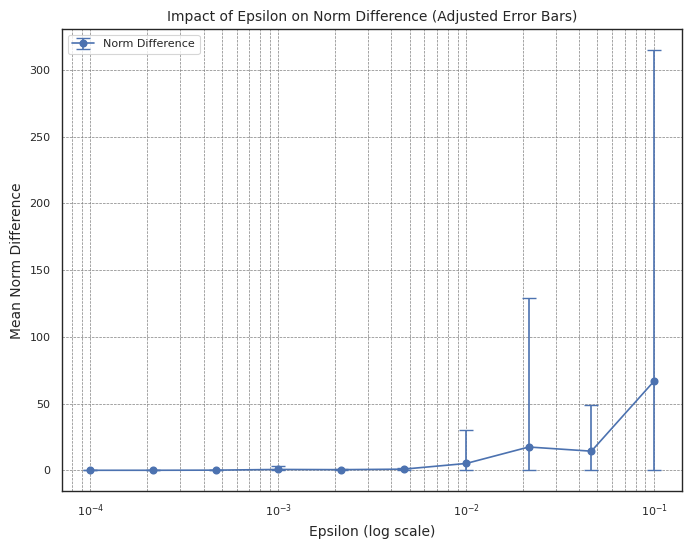

In [66]:
# Parameters for the experiment
epsilons = np.logspace(-4, -1, 10)  # Epsilon values from 1e-4 to 1e-1
num_samples = 100  # Number of samples per epsilon


# Function to compute the norm difference for a given epsilon
def compute_norm_difference(epsilon):
    # Transformation matrix for t1
    t1_w = np.random.rand(2, 2)  # Random 2x2 matrix for t1
    t1_b = np.array([[0], [0]])  # No bias

    # Transformation matrix for t2
    t2_w = t1_w + epsilon * np.random.randn(2, 2)  # Add small random noise
    t2_b = np.array([[0], [0]])  # No bias

    # Apply transformations
    t1_x = np.maximum(t1_w @ x + t1_b, 0)  # ReLU
    t2_t1_x = np.maximum(t2_w @ t1_x + t2_b, 0)  # ReLU

    # Undo transformations
    x_0 = -np.linalg.inv(t1_w) @ t1_b
    alpha_1 = t1_w @ (t2_t1_x - x_0)
    alpha_1[alpha_1 >= 0] = 0
    recons_t1_x = np.linalg.inv(t1_w) @ (t2_t1_x - t1_b + alpha_1)

    # Compute norm difference
    return np.linalg.norm(recons_t1_x - t1_x)


# Perform the experiment
results = []
for epsilon in epsilons:
    norms = [compute_norm_difference(epsilon) for _ in range(num_samples)]
    mean_norm = np.mean(norms)
    std_norm = np.std(norms)
    print("mean", mean_norm)
    print("std", std_norm)
    results.append((epsilon, mean_norm, std_norm))

# Extract results for plotting
epsilons, mean_norms, std_norms = zip(*results)

# Compute error bounds for plotting
lower_bounds = [max(0, mean - std) for mean, std in zip(mean_norms, std_norms)]
upper_bounds = [mean + std for mean, std in zip(mean_norms, std_norms)]

# Plot the results with adjusted error bars
plt.figure(figsize=(8, 6))
plt.errorbar(
    epsilons,
    mean_norms,
    yerr=[mean_norms - np.array(lower_bounds), np.array(upper_bounds) - mean_norms],
    fmt="-o",
    capsize=5,
    label="Norm Difference",
)
plt.xscale("log")
plt.xlabel("Epsilon (log scale)")
plt.ylabel("Mean Norm Difference")
plt.title("Impact of Epsilon on Norm Difference (Adjusted Error Bars)")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


In [67]:
x = np.vstack((x_coords, y_coords))

# Transformation matrix for t1
t1_w = np.random.rand(2, 2)  # Random 2x2 matrix for t1
t1_b = np.array([[-0.2], [0.2]])  # No bias

# Transformation matrix for t2
epsilon = 2e-5
t2_w = t1_w + epsilon * np.random.randn(2, 2)  # Add small random noise
t2_b = np.array([[-0.15], [0.15]])  # No bias


In [74]:
# Define subplots
fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[
        "x",
        "t1(x)",
        "t2(t1(x))",
        "x",
        "undo t2 on t2(t1(x))",
        "undo t1 on t2(t1(x))",
    ],
    shared_xaxes=True,
    shared_yaxes=True,  # Ensure shared axes for consistent scaling
)

# Define fixed range for all plots
fixed_x_range = [-3, 3]
fixed_y_range = [-3, 3]

# Simplified axis range updates
fig.update_layout(
    height=800,
    width=1200,
    title="Transformations with Fixed Scaling",
    xaxis_range=fixed_x_range,
    yaxis_range=fixed_y_range,
)

# Apply the same range to all axes dynamically
for axis in fig.layout:
    if axis.startswith("xaxis") or axis.startswith("yaxis"):
        fig.layout[axis].update(
            range=fixed_x_range if axis.startswith("xaxis") else fixed_y_range, scaleanchor="y"
        )

style = dict(size=5, color="blue", opacity=0.5)


In [ ]:
# Apply transformations
t1_x = relu_mul(t1_w @ x + t1_b)  # ReLU
t2_t1_x = relu_mul(t2_w @ t1_x + t2_b)  # ReLU

# First row
# Plot Original Points
fig.add_trace(go.Scatter(x=x[0], y=x[1], mode="markers", marker=style), row=1, col=1)
# Plot t1 Transformed Points
fig.add_trace(go.Scatter(x=t1_x[0], y=t1_x[1], mode="markers", marker=style), row=1, col=2)
# Plot t2 ∘ t1 Transformed Points
fig.add_trace(go.Scatter(x=t2_t1_x[0], y=t2_t1_x[1], mode="markers", marker=style), row=1, col=3)

# First row
# Plot Original Points
fig.add_trace(go.Scatter(x=x[0], y=x[1], mode="markers", marker=style), row=2, col=1)

# Undo t2 on t2(t1(x))
x_0 = -np.linalg.inv(t2_w) @ t2_b
alpha = t2_w @ (t1_x - x_0)
alpha[alpha >= 0] = 0
recons_t1_x = np.linalg.inv(t2_w) @ (t2_t1_x - t2_b + alpha)
fig.add_trace(
    go.Scatter(x=recons_t1_x[0], y=recons_t1_x[1], mode="markers", marker=style), row=2, col=2
)

# Undo t1 on t2(t1(x))
x_0 = -np.linalg.inv(t1_w) @ t1_b
alpha = t1_w @ (t1_x - x_0)
alpha[alpha >= 0] = 0
recons_t1_x = np.linalg.inv(t1_w) @ (t2_t1_x - t1_b + alpha)
fig.add_trace(
    go.Scatter(x=recons_t1_x[0], y=recons_t1_x[1], mode="markers", marker=style), row=2, col=3
)

print(np.linalg.norm((recons_t1_x) - t1_x))

fig.show()

23.041209606414213
